In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [123]:
df1 = pd.read_csv(f'data\AEP_hourly.csv', index_col='Datetime')
df2 = pd.read_csv(f'data\COMED_hourly.csv', index_col='Datetime')
df3 = pd.read_csv(f'data\DAYTON_hourly.csv', index_col='Datetime')
df4 = pd.read_csv(f'data\DEOK_hourly.csv', index_col='Datetime')
df5 = pd.read_csv(f'data\DOM_hourly.csv', index_col='Datetime')
df6 = pd.read_csv(f'data\DUQ_hourly.csv', index_col='Datetime')
df7 = pd.read_csv(f'data\EKPC_hourly.csv', index_col='Datetime')
df8 = pd.read_csv(f'data\FE_hourly.csv', index_col='Datetime')
df9 = pd.read_csv(r'data\NI_hourly.csv', index_col='Datetime')
df10 = pd.read_csv(f'data\PJME_hourly.csv', index_col='Datetime')
df11 = pd.read_csv(f'data\PJMW_hourly.csv', index_col='Datetime')

df_final = df1.join([df2,df3,df4,df5,df6,df7,df8,df9,df10,df11])

# print first five row
df_final.head()

,AEP_MW,COMED_MW,DAYTON_MW,DEOK_MW,DOM_MW,DUQ_MW,EKPC_MW,FE_MW,NI_MW,PJME_MW,PJMW_MW
Datetime,,,,,,,,,,,
2004-12-31 01:00:00,13478.0,NaN,1596.0,NaN,NaN,NaN,NaN,NaN,9810.0,27160.0,5285.0
2004-12-31 02:00:00,12865.0,NaN,1517.0,NaN,NaN,NaN,NaN,NaN,9001.0,25791.0,5085.0
2004-12-31 03:00:00,12577.0,NaN,1486.0,NaN,NaN,NaN,NaN,NaN,8509.0,25052.0,4944.0
2004-12-31 04:00:00,12517.0,NaN,1469.0,NaN,NaN,NaN,NaN,NaN,8278.0,24797.0,4916.0
2004-12-31 05:00:00,12670.0,NaN,1472.0,NaN,NaN,NaN,NaN,NaN,8089.0,25026.0,4960.0


In [124]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 125361 entries, 2004-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AEP_MW     125361 non-null  float64
 1   COMED_MW   70583 non-null   float64
 2   DAYTON_MW  125361 non-null  float64
 3   DEOK_MW    61825 non-null   float64
 4   DOM_MW     120275 non-null  float64
 5   DUQ_MW     123154 non-null  float64
 6   EKPC_MW    49421 non-null   float64
 7   FE_MW      66960 non-null   float64
 8   NI_MW      54778 non-null   float64
 9   PJME_MW    125361 non-null  float64
 10  PJMW_MW    125361 non-null  float64
dtypes: float64(11)
memory usage: 11.5+ MB


The AEP means American Electric Power and this dataframe refers to the whole American Consumption. <br>
Each an every of the other dataframes refer to different cities.

In [125]:
df_final.describe()

,AEP_MW,COMED_MW,DAYTON_MW,DEOK_MW,DOM_MW,DUQ_MW,EKPC_MW,FE_MW,NI_MW,PJME_MW,PJMW_MW
count,125361.000000,70583.000000,125361.000000,61825.000000,120275.000000,123154.000000,49421.000000,66960.000000,54778.000000,125361.000000,125361.000000
mean,15363.077847,11237.756174,2017.668996,3041.597541,10845.028119,1642.043401,1435.357722,7663.627688,11713.761236,31759.038983,5531.513541
std,2661.589281,2357.022834,402.920846,637.299488,2438.253016,310.399093,382.815695,1386.468697,2363.414180,6643.720256,1008.678744
min,9581.000000,7237.000000,982.000000,907.000000,1253.000000,1014.000000,514.000000,0.000000,7003.000000,14544.000000,2553.000000
25%,13416.000000,9496.000000,1716.000000,2594.000000,9154.000000,1423.000000,1153.000000,6608.000000,9981.000000,27103.000000,4788.000000
50%,15206.000000,11018.000000,1994.000000,2971.000000,10402.000000,1618.000000,1365.000000,7606.000000,11530.000000,31182.000000,5447.000000
75%,17121.000000,12397.000000,2267.000000,3409.000000,12287.500000,1811.000000,1667.000000,8483.000000,12891.000000,35451.000000,6199.000000
max,25695.000000,23753.000000,3746.000000,5445.000000,21651.000000,3054.000000,3490.000000,14032.000000,23631.000000,62009.000000,9594.000000


In [126]:
print(f'The minimum Datetime observed is: {df_final.index.min()}')
print(f'The maximum Datetime observed is: {df_final.index.max()}')

The minimum Datetime observed is: 2004-10-01 01:00:00
The maximum Datetime observed is: 2018-08-03 00:00:00


Text(0.5, 1.0, 'PJM Energy Consumption')

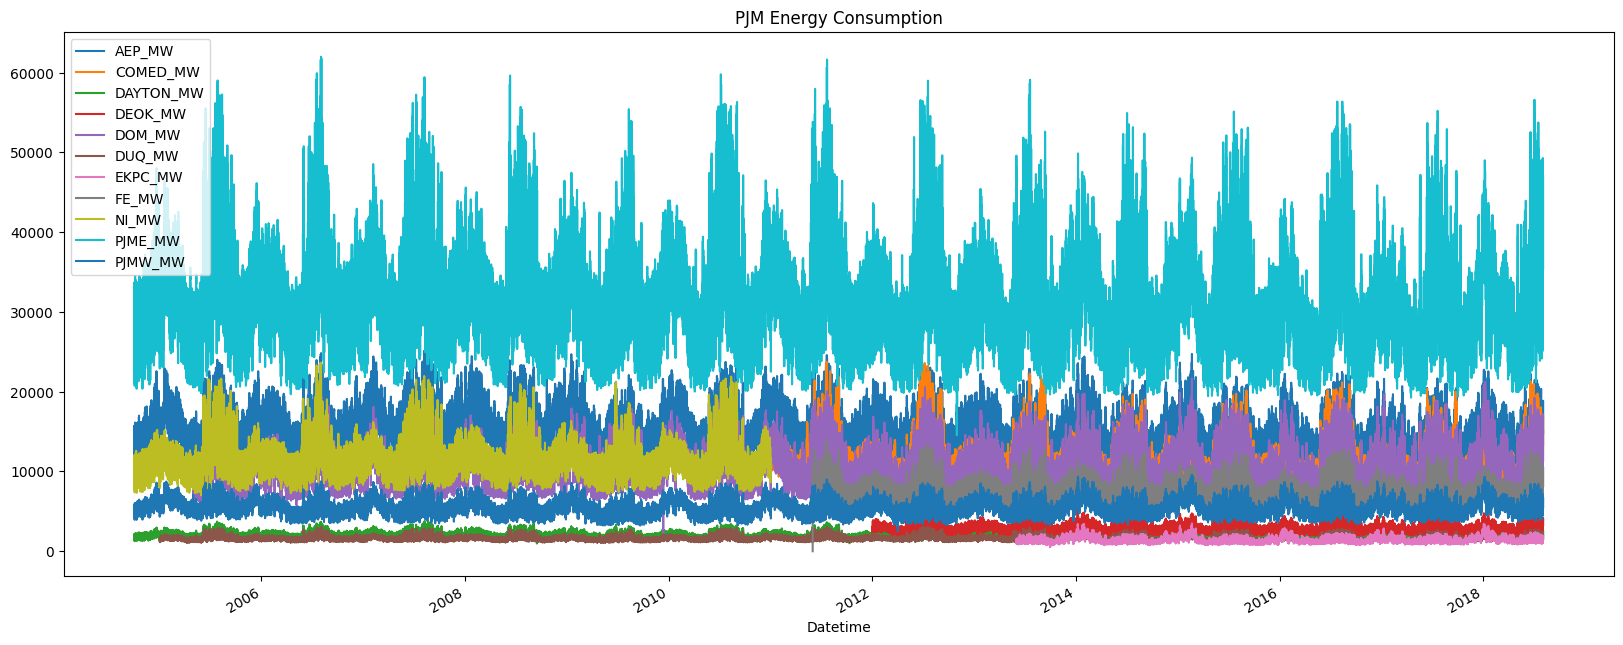

In [127]:
df_final= df_final.sort_index()

df_final.index = pd.to_datetime(df_final.index)

df_final.plot(figsize=(20,8))
plt.title('PJM Energy Consumption')

As we can see from the last plot we cannot make any knowledge (plot is completely messy).

Text(0.5, 1.0, 'PJM Energy Consumption for 2018')

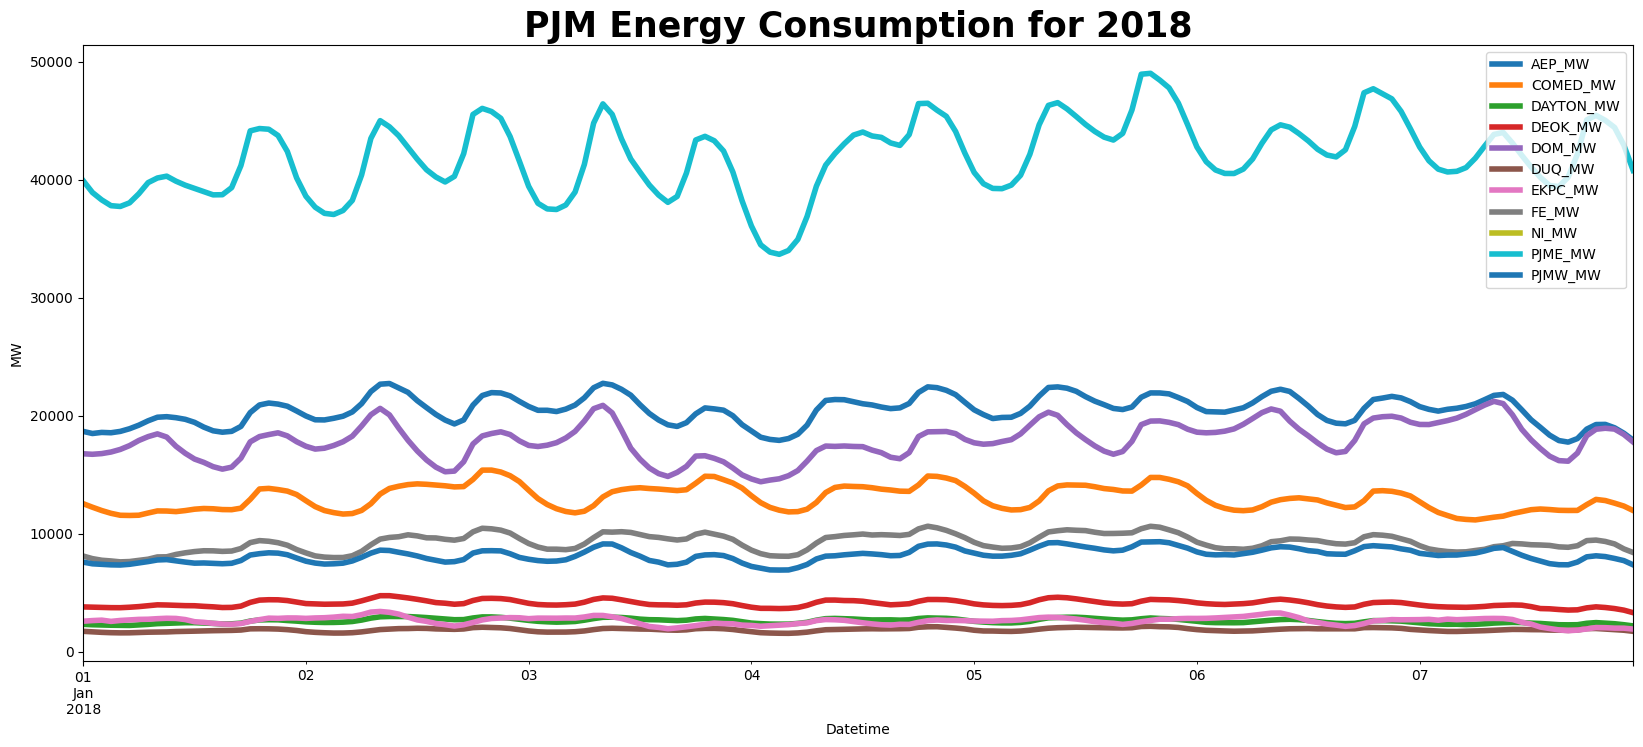

In [128]:
df_2018 = df_final[(df_final.index>='2018-01-01')& (df_final.index < '2018-01-08')]
df_2018.plot(figsize=(20,8),lw=4)
plt.ylabel('MW')
plt.title('PJM Energy Consumption for 2018', weight='bold', fontsize=25)

In [129]:
df_final.isnull().sum()

AEP_MW           0
COMED_MW     54778
DAYTON_MW        0
DEOK_MW      63536
DOM_MW        5086
DUQ_MW        2207
EKPC_MW      75940
FE_MW        58401
NI_MW        70583
PJME_MW          0
PJMW_MW          0
dtype: int64

In [130]:
df_final['Hour'] = df_final.index.hour
df_final['Month'] = df_final.index.month
df_final['Year'] = df_final.index.year
df_final['Day'] = df_final.index.day

In [131]:
df_final.head()

,AEP_MW,COMED_MW,DAYTON_MW,DEOK_MW,DOM_MW,DUQ_MW,EKPC_MW,FE_MW,NI_MW,PJME_MW,PJMW_MW,Hour,Month,Year,Day
Datetime,,,,,,,,,,,,,,,
2004-10-01 01:00:00,12379.0,NaN,1621.0,NaN,NaN,NaN,NaN,NaN,9305.0,24025.0,4628.0,1,10,2004,1
2004-10-01 02:00:00,11935.0,NaN,1536.0,NaN,NaN,NaN,NaN,NaN,8681.0,22845.0,4520.0,2,10,2004,1
2004-10-01 03:00:00,11692.0,NaN,1500.0,NaN,NaN,NaN,NaN,NaN,8314.0,22138.0,4431.0,3,10,2004,1
2004-10-01 04:00:00,11597.0,NaN,1434.0,NaN,NaN,NaN,NaN,NaN,8094.0,21922.0,4383.0,4,10,2004,1
2004-10-01 05:00:00,11681.0,NaN,1489.0,NaN,NaN,NaN,NaN,NaN,8041.0,22193.0,4460.0,5,10,2004,1


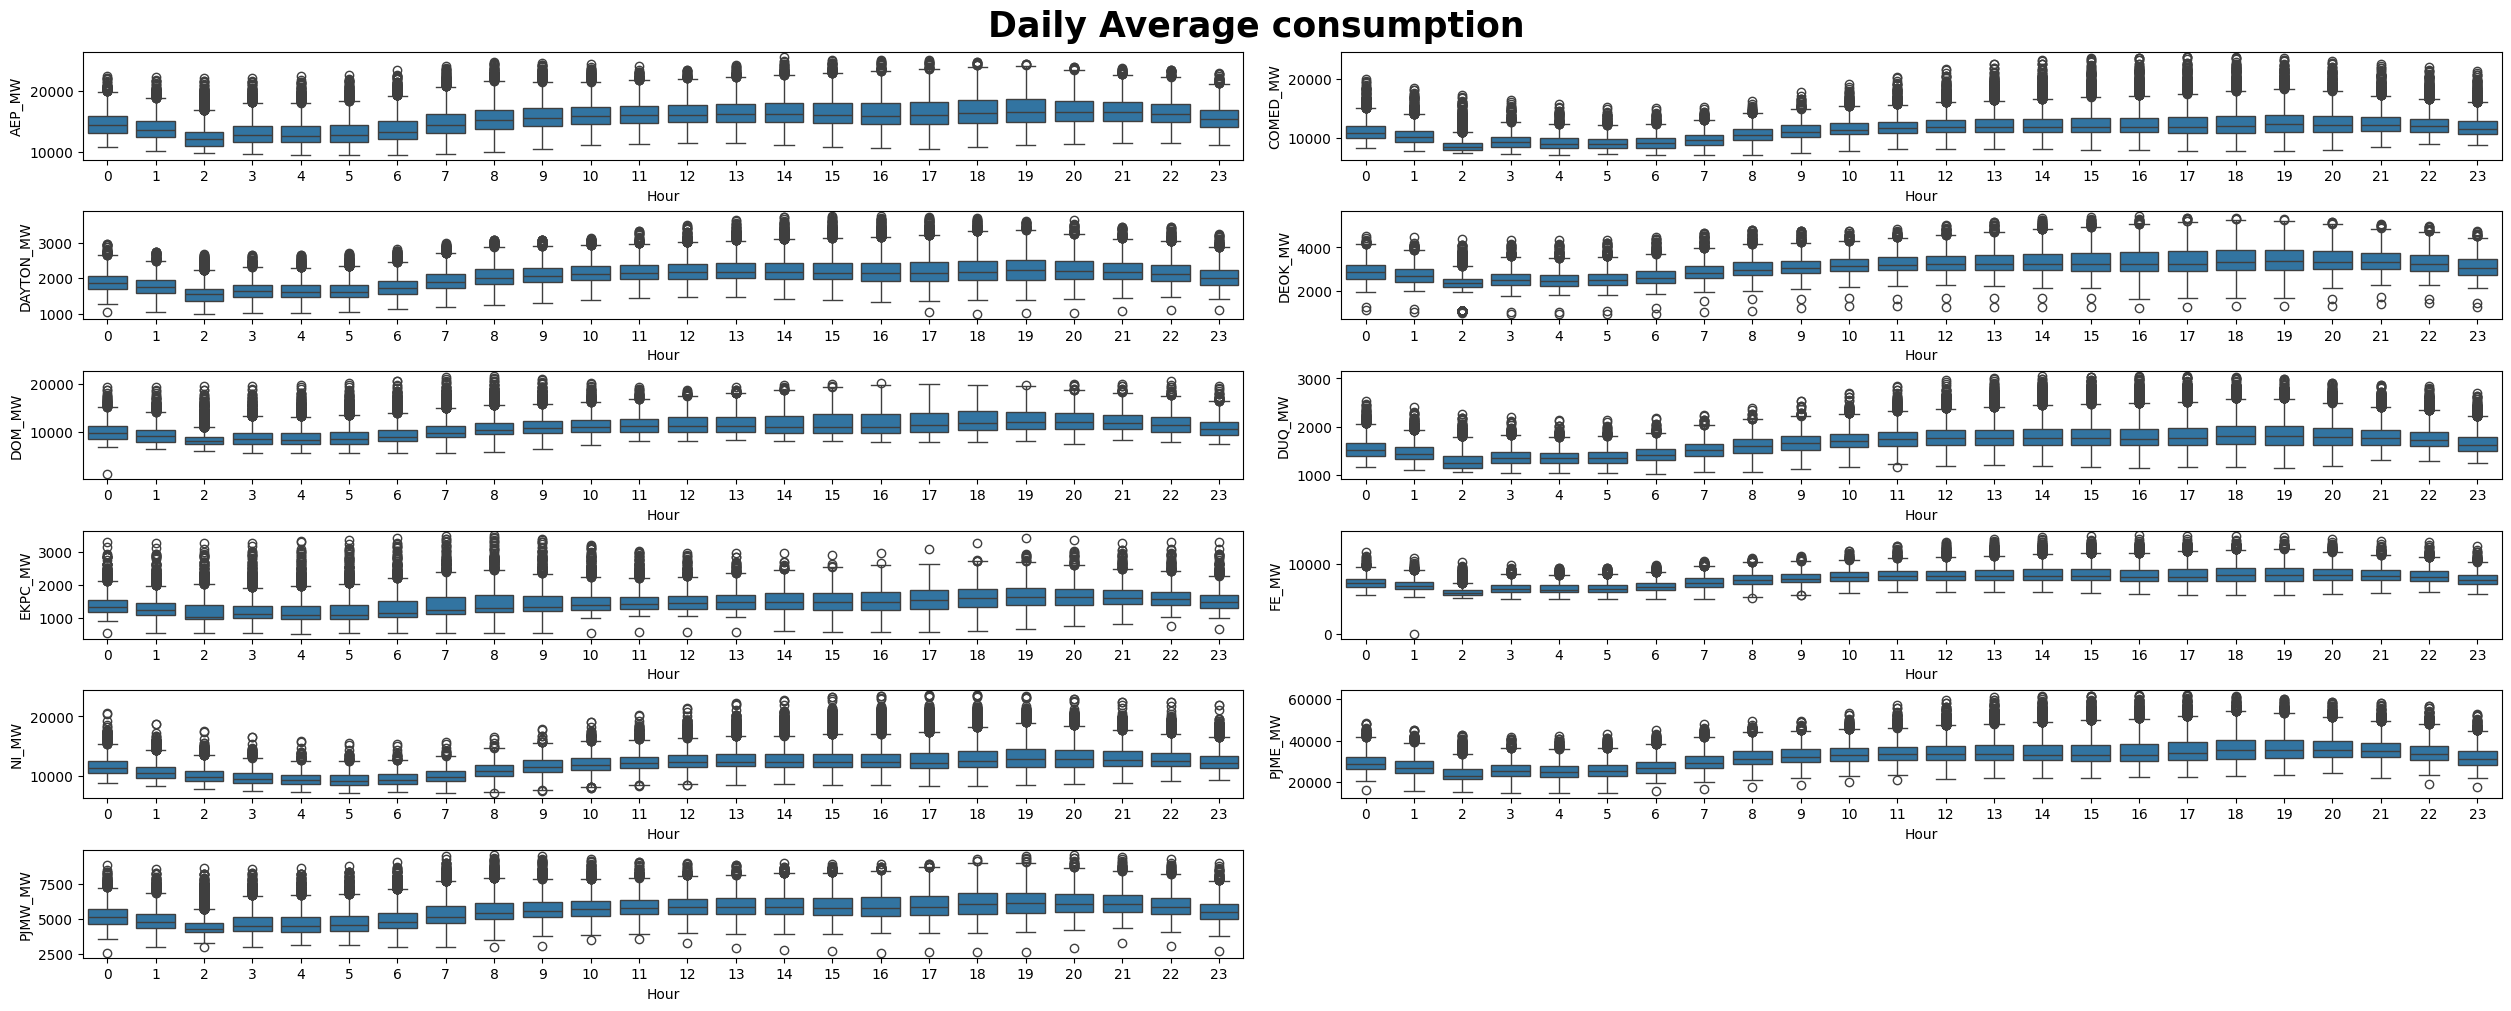

In [132]:
columns = ['AEP_MW', 'COMED_MW', 'DAYTON_MW', 'DEOK_MW', 'DOM_MW', 'DUQ_MW',
           'EKPC_MW', 'FE_MW', 'NI_MW', 'PJME_MW', 'PJMW_MW']

df_final = df_final.reset_index(drop=True)

fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Daily Average consumption', weight = 'bold',fontsize=25)
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Hour", y=col, ax = ax[i])

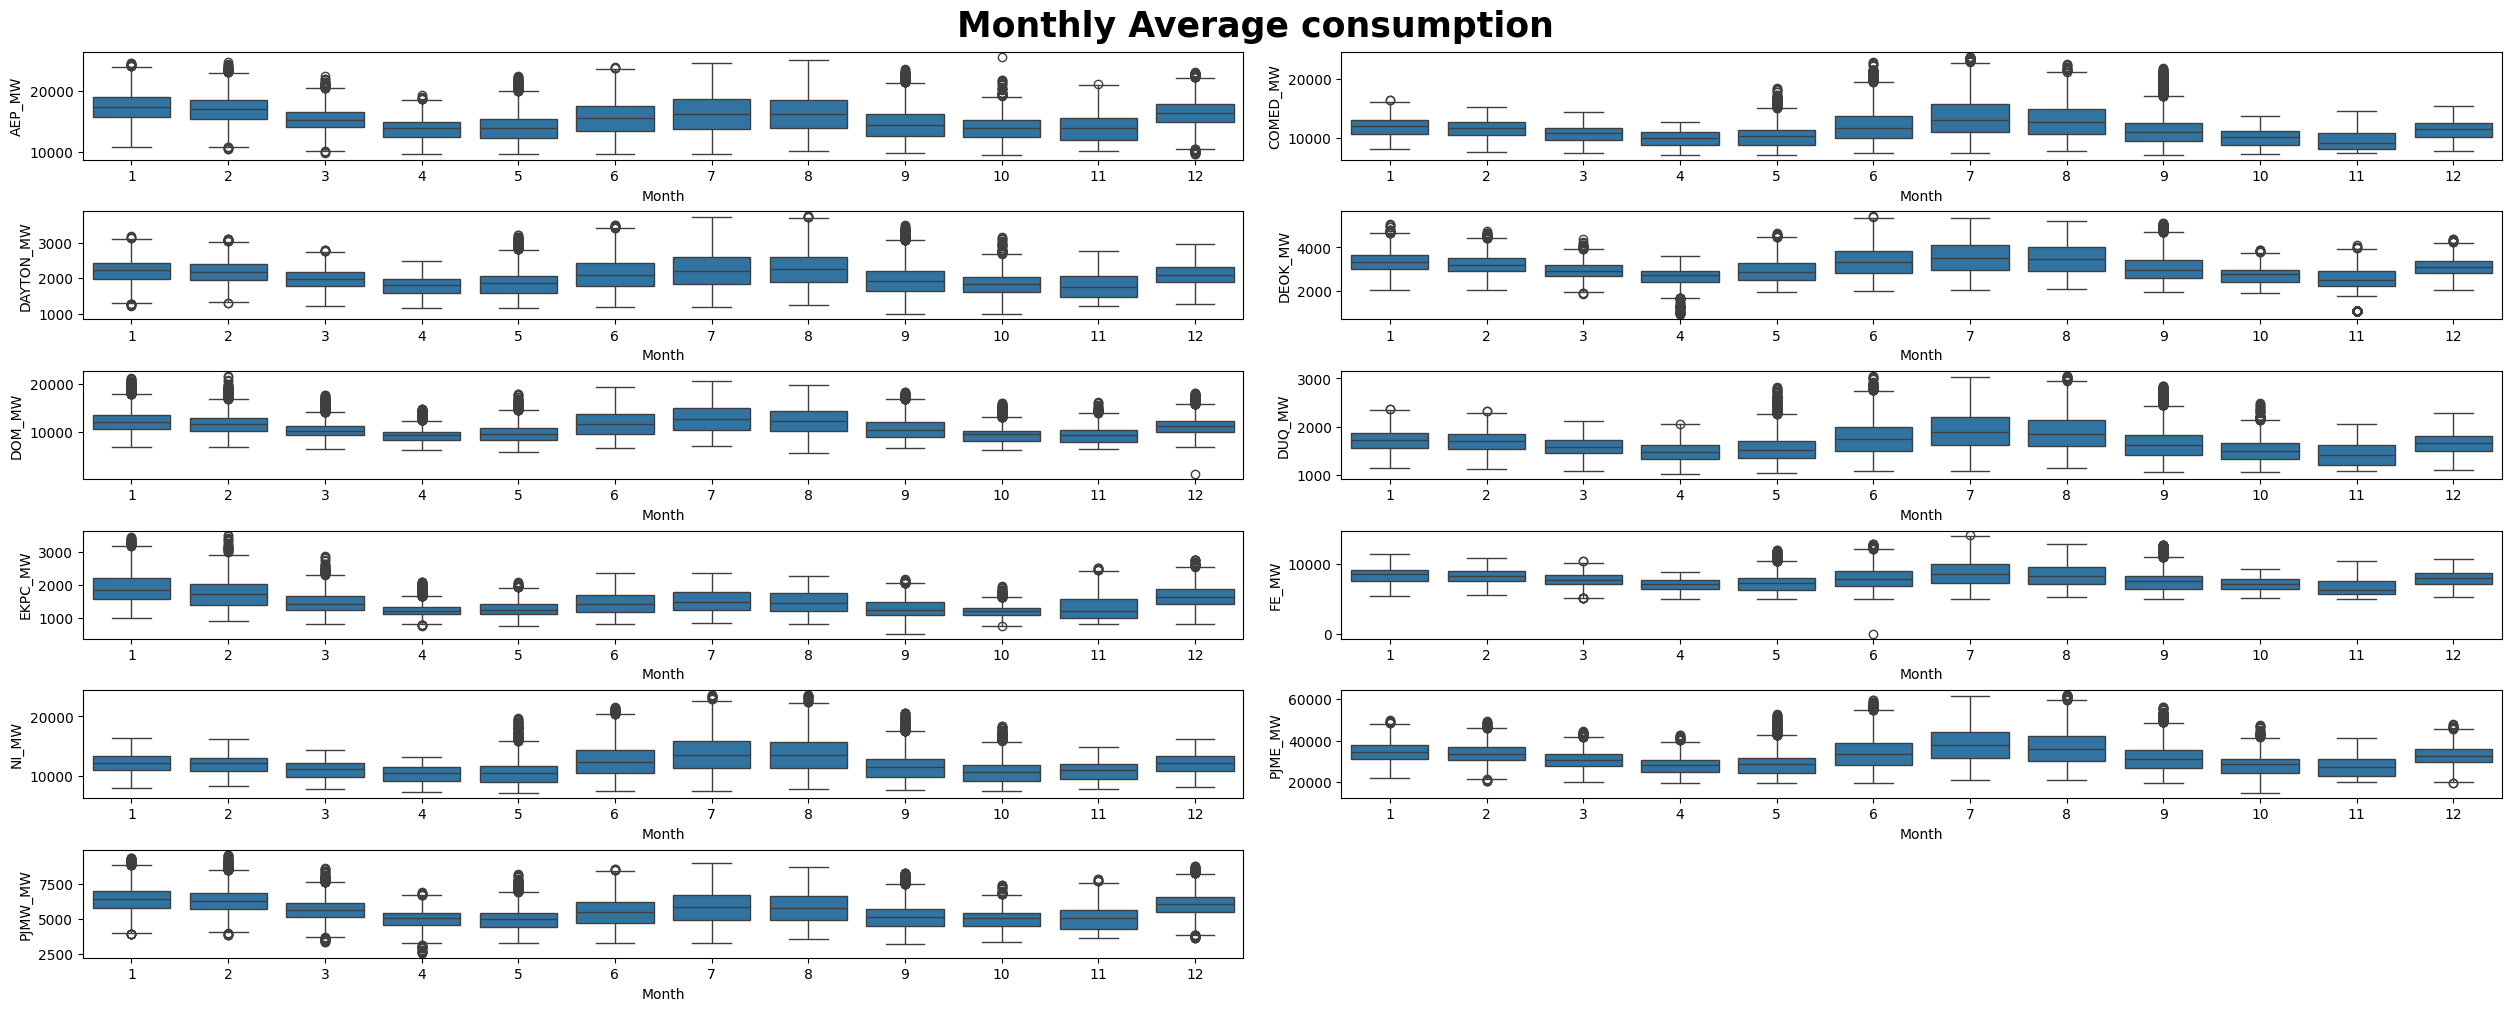

In [133]:
fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Monthly Average consumption', weight = 'bold',fontsize=25)
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Month", y=col, ax = ax[i])

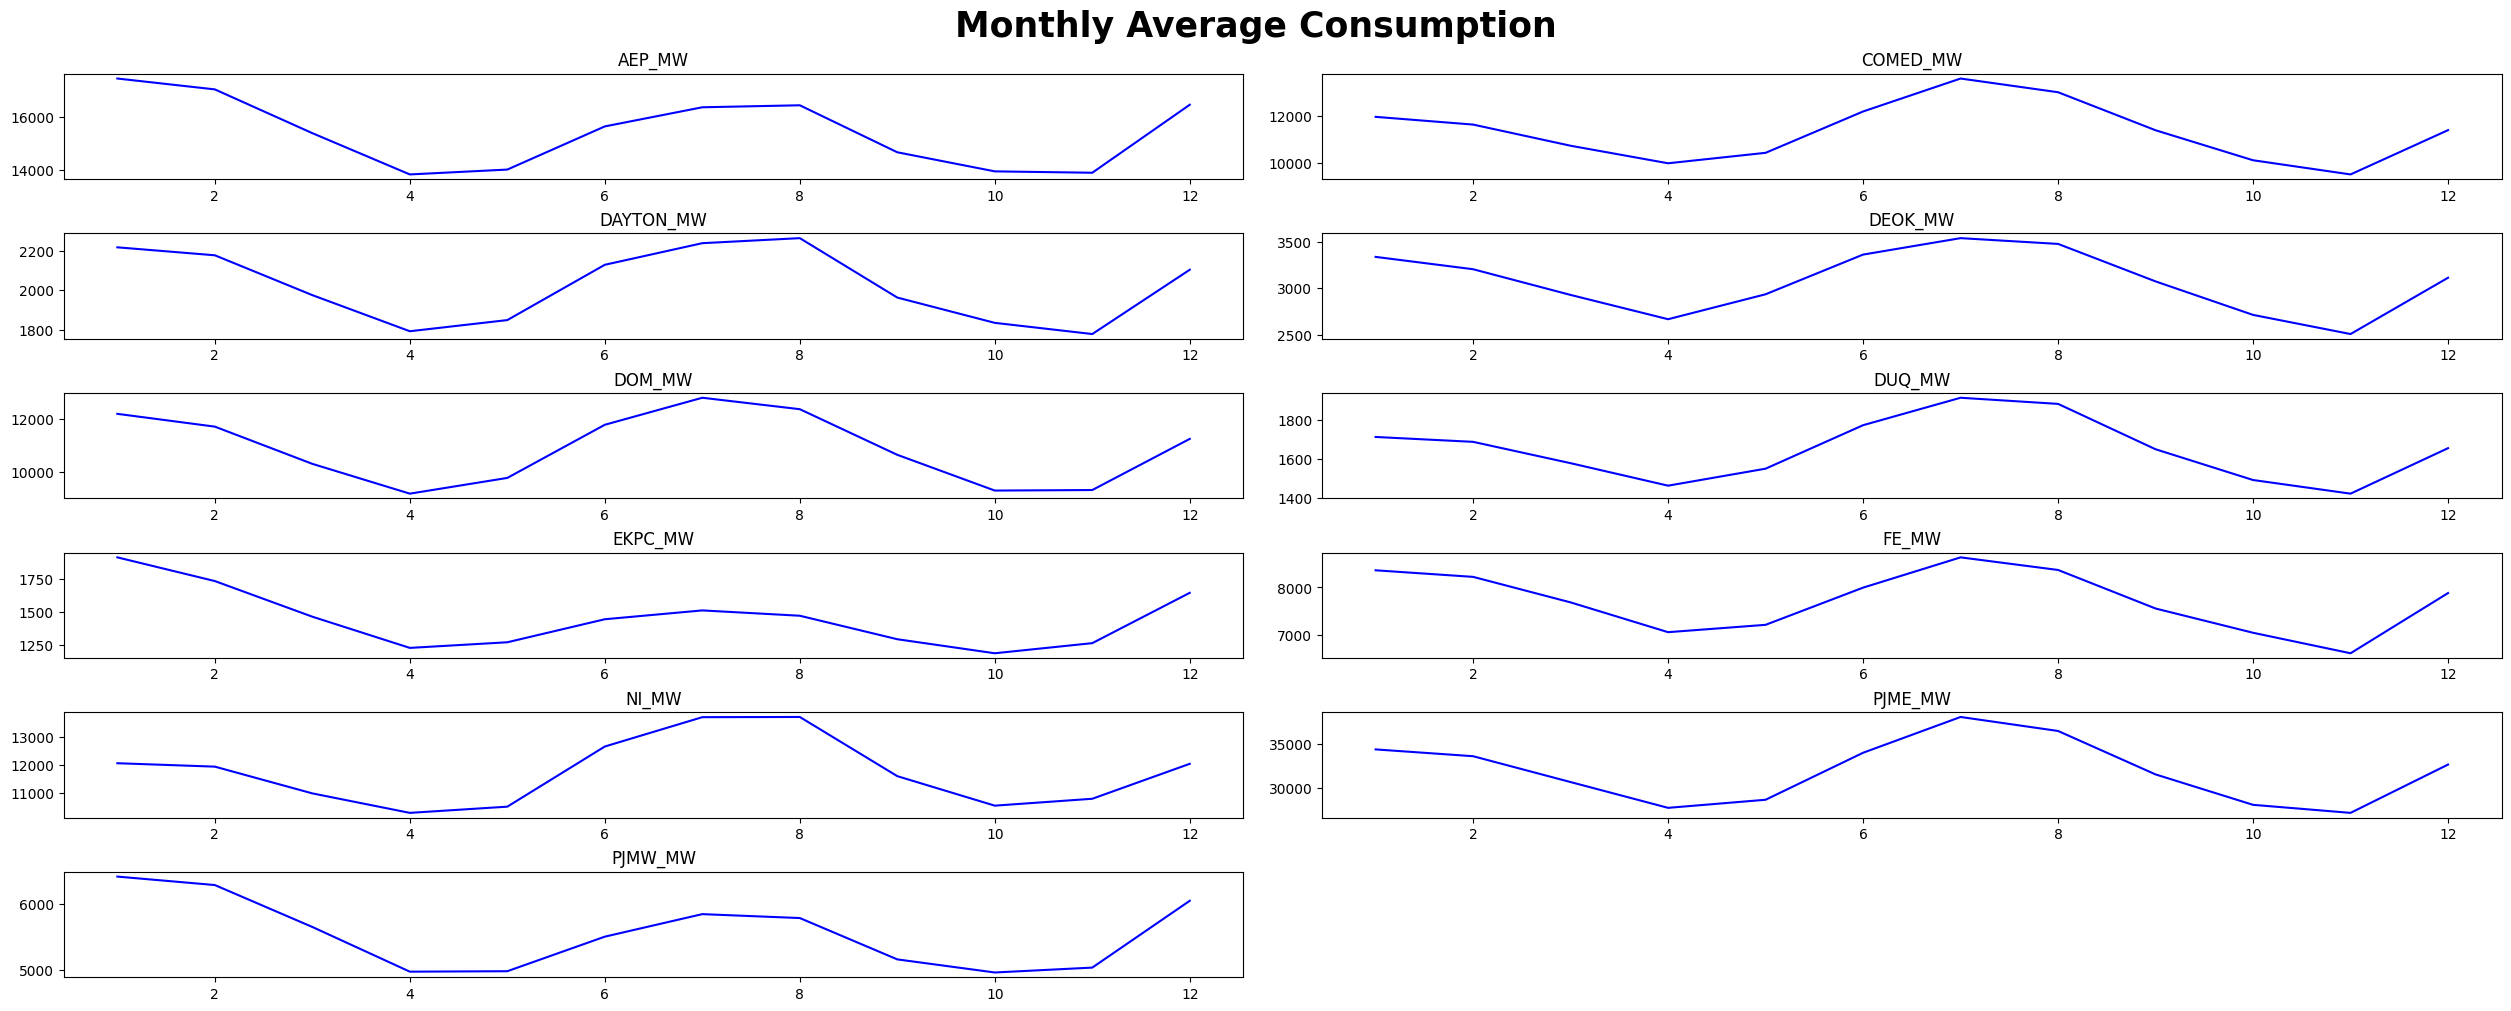

In [134]:
fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(25,10), constrained_layout=True)
fig.suptitle('Monthly Average Consumption', weight='bold', fontsize=25)

ax = ax.flatten()
fig.delaxes(ax[-1])

df_monthly = df_final.groupby("Month")[columns].mean()
df_monthly = df_monthly.sort_index()

for i, col in enumerate(columns):
    ax[i].plot(df_monthly.index, df_monthly[col], color='blue')
    ax[i].set_title(col)

We can see that the time series during the months there are seasonal data.

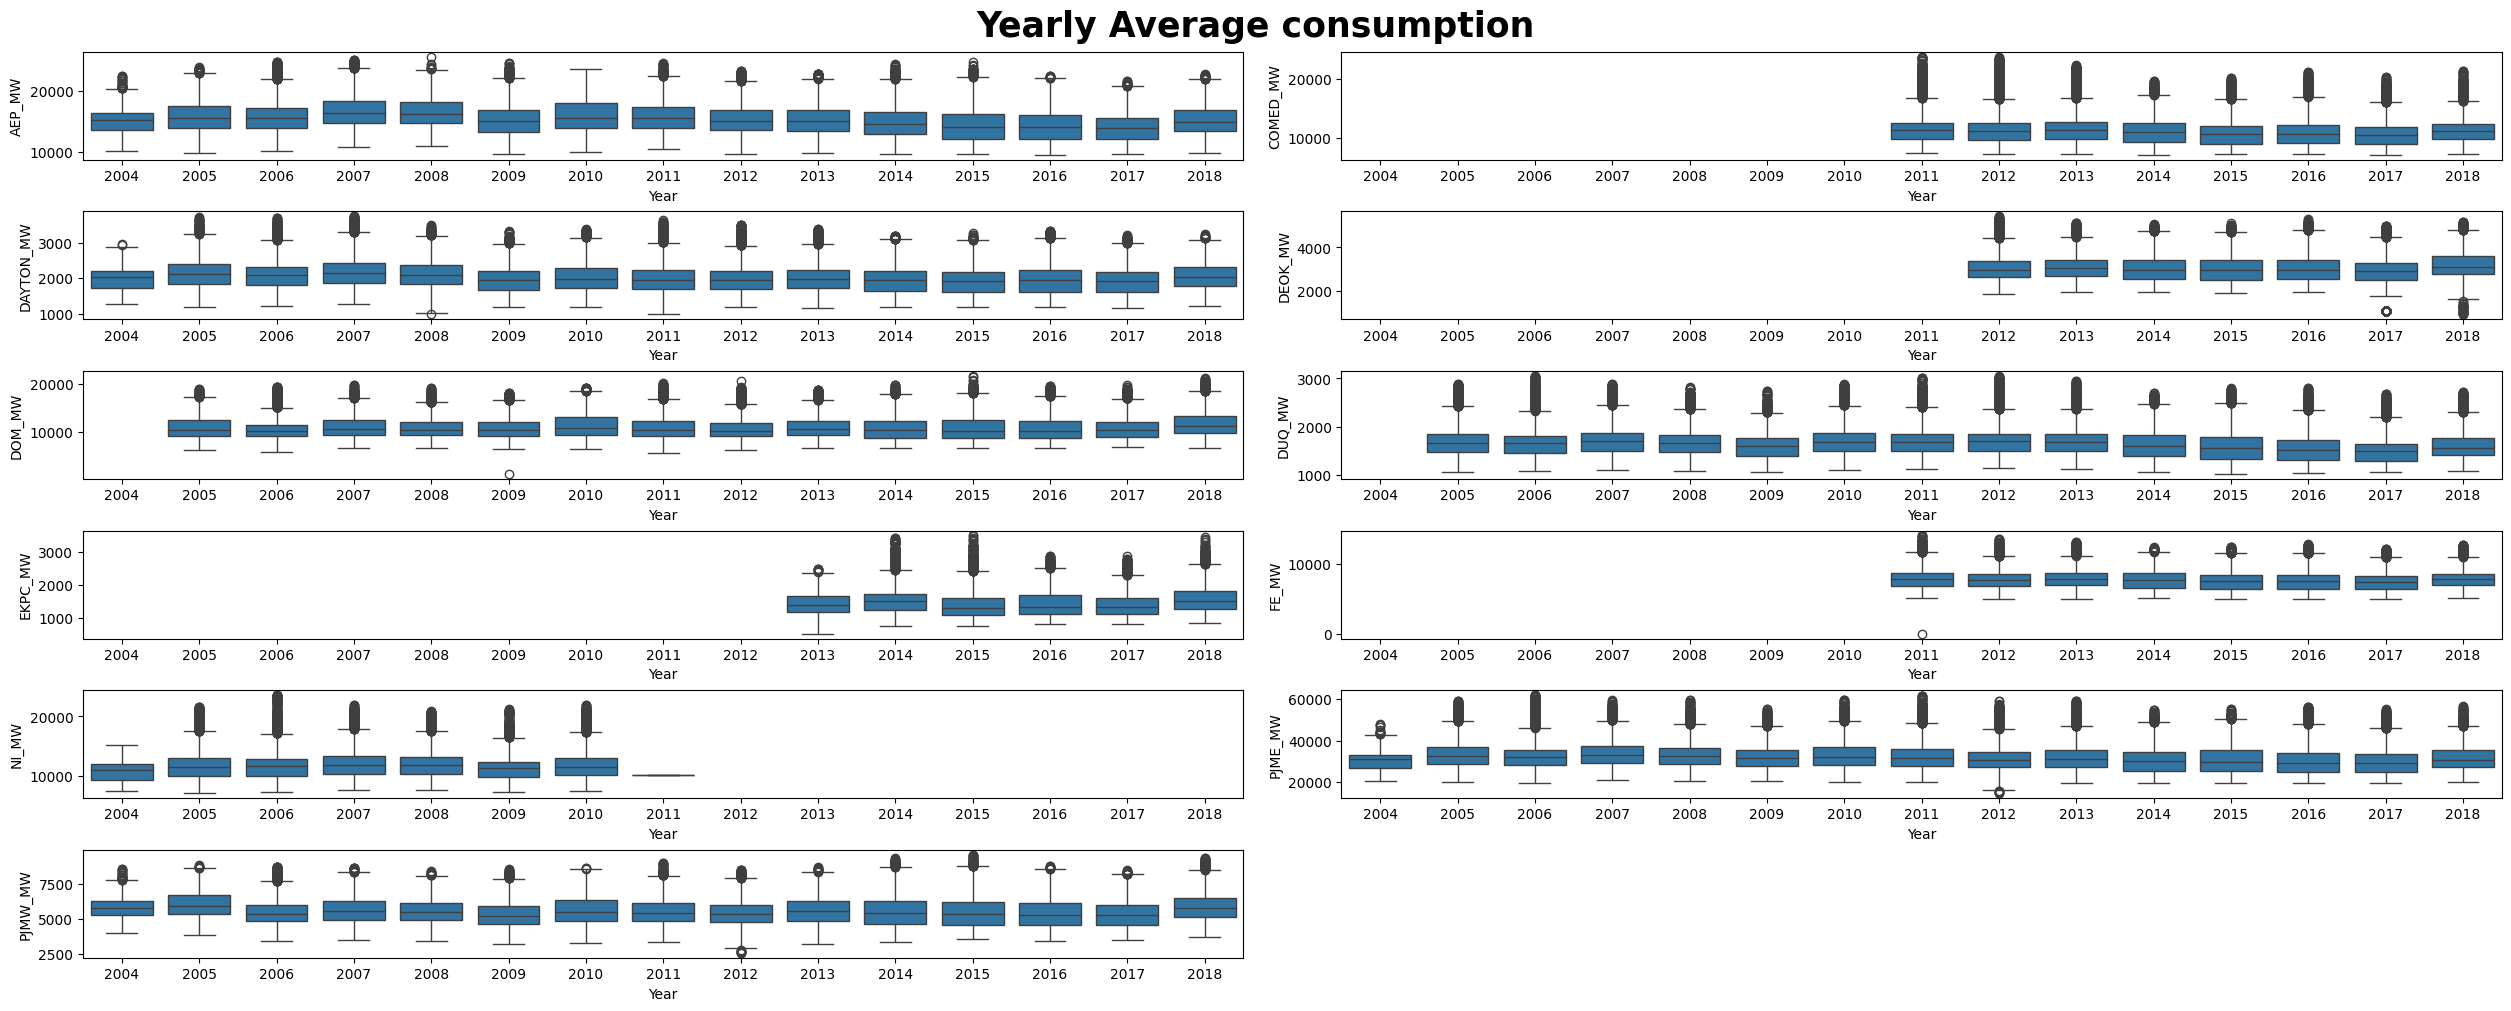

In [135]:
fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Yearly Average consumption', weight = 'bold',fontsize=25)
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Year", y=col, ax = ax[i])

So the null data for few of the columns are that they dont have data for some of the years.

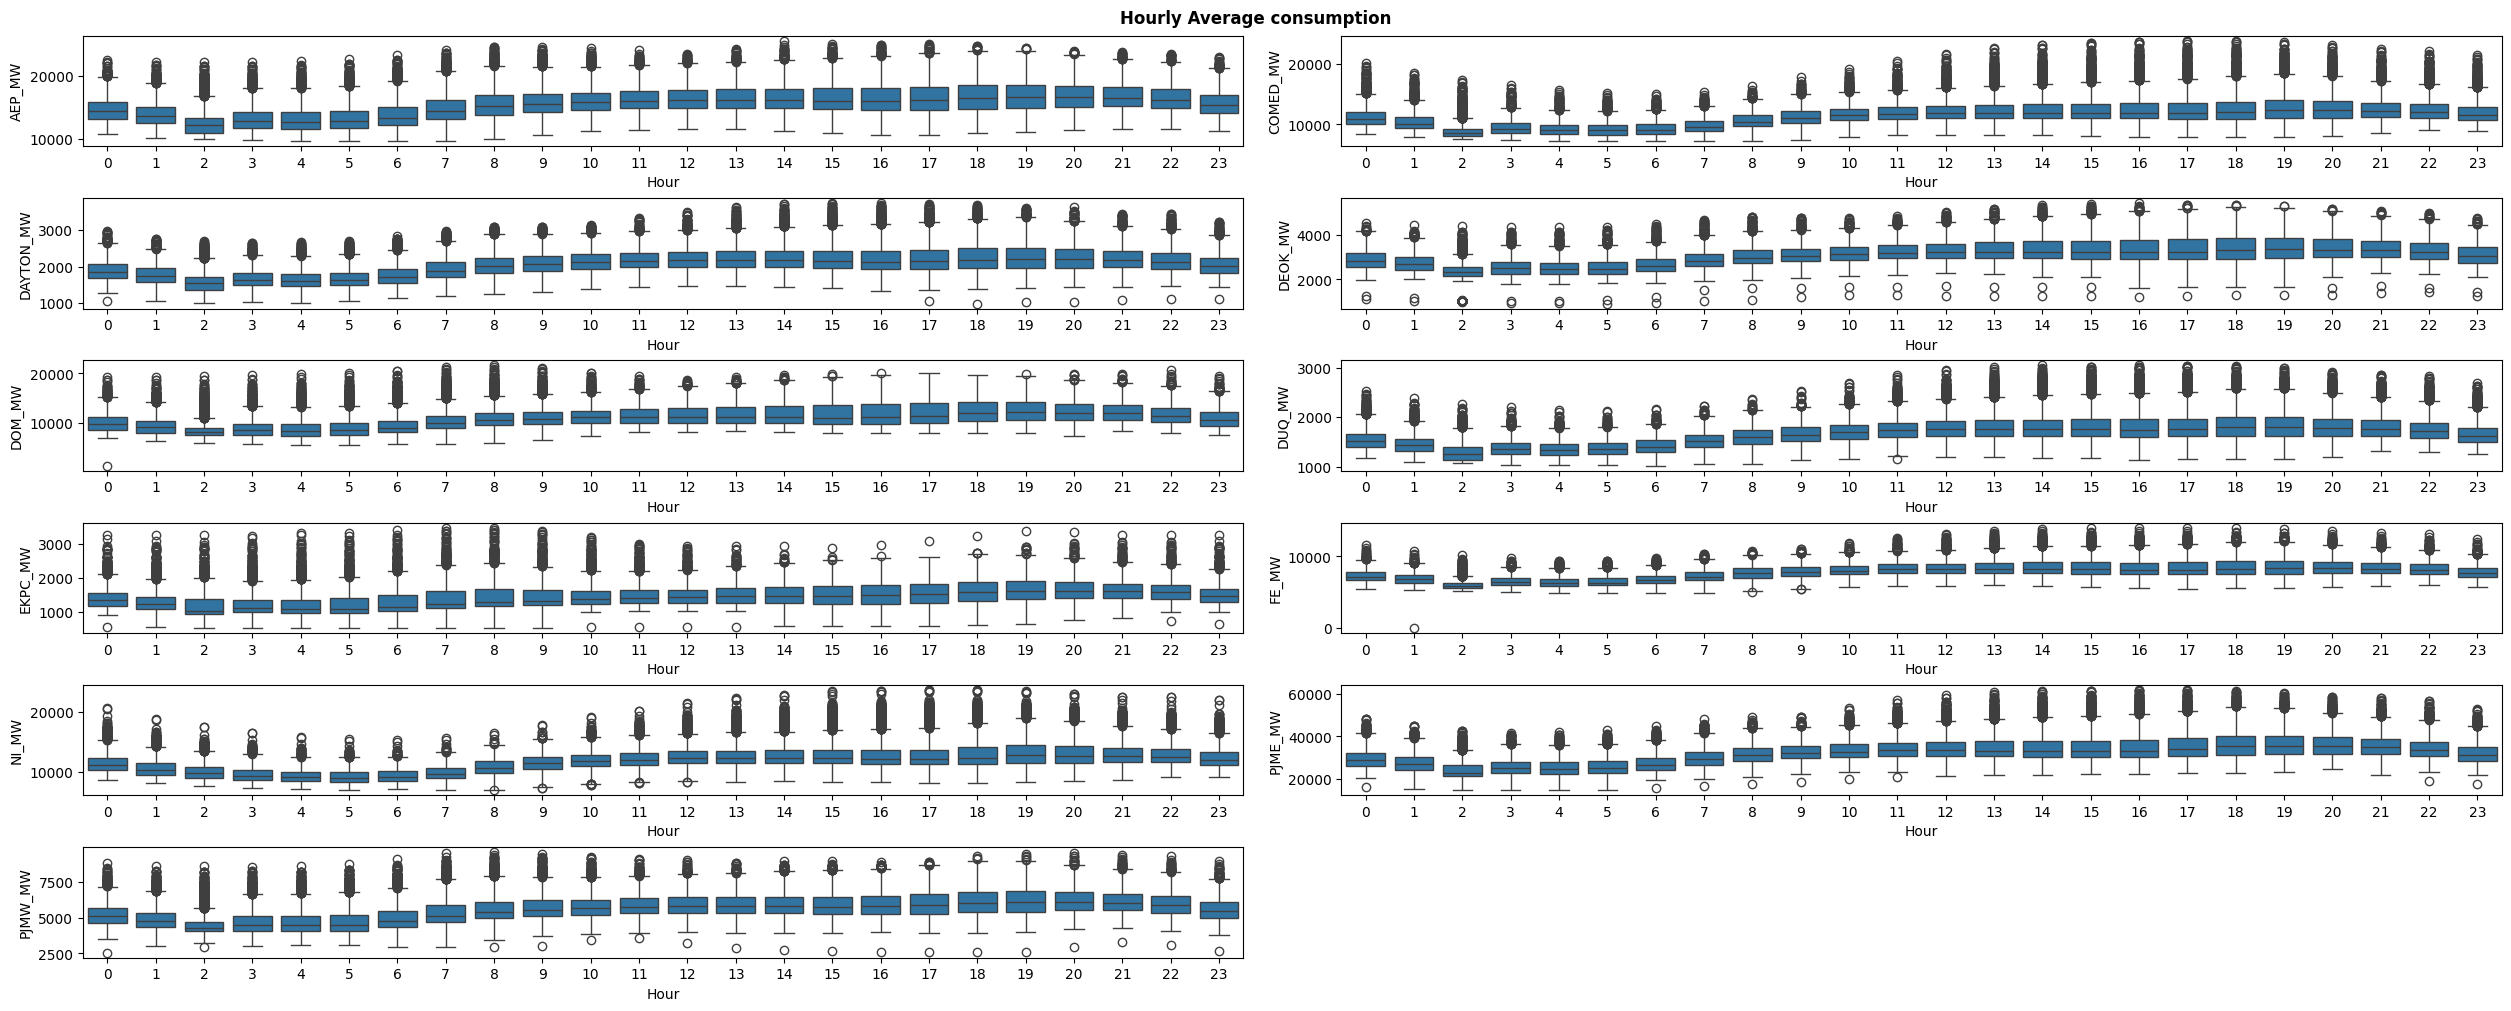

In [136]:
fig, ax = plt.subplots(nrows = 6, ncols = 2, figsize = (25,10),constrained_layout = True)
fig.suptitle('Hourly Average consumption', weight = 'bold')
fig.delaxes(ax[5][1])
ax = ax.flatten()

for i,col in enumerate(columns):
    sns.boxplot(data = df_final, x = "Hour", y=col, ax = ax[i])

I will use the dataframe only for the Dayton mw since the analysis after that will have the same logic as this.

In [216]:
# Dayton_mw df is the df3
df = df3
df.head()


,DAYTON_MW
Datetime,
2004-12-31 01:00:00,1596.0
2004-12-31 02:00:00,1517.0
2004-12-31 03:00:00,1486.0
2004-12-31 04:00:00,1469.0
2004-12-31 05:00:00,1472.0


In [138]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# The data that we are going to use (DAYTON)
df.head()

,DAYTON_MW
Datetime,
2004-10-01 01:00:00,1621.0
2004-10-01 02:00:00,1536.0
2004-10-01 03:00:00,1500.0
2004-10-01 04:00:00,1434.0
2004-10-01 05:00:00,1489.0


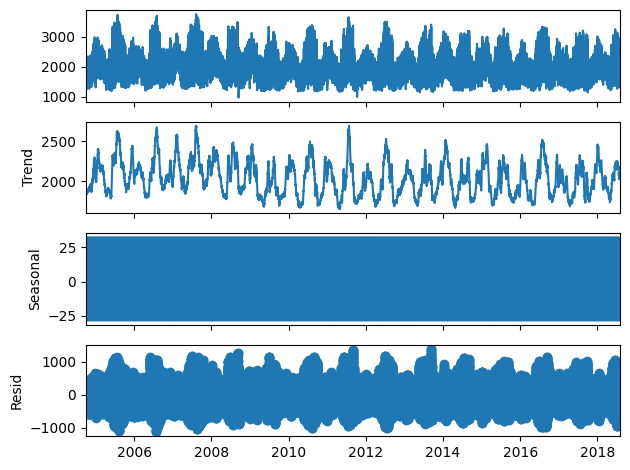

In [139]:
from statsmodels.tsa.seasonal import seasonal_decompose
seasonal_decompose(df, period=365).plot()
plt.show()

# Simple Moving Average  Function

In [140]:
ma = df.resample('D').mean() # D means daily

# 3 Day Example
ma['Moving Average'] = ma['DAYTON_MW'].rolling(3).mean()
ma.head()

,DAYTON_MW,Moving Average
Datetime,,
2004-10-01,1924.130435,NaN
2004-10-02,1641.583333,NaN
2004-10-03,1528.708333,1698.140700
2004-10-04,1926.541667,1698.944444
2004-10-05,1970.125000,1808.458333


In [141]:
def moving_average(data, window):
    data['Moving Average'] = data['DAYTON_MW'].rolling(window).mean()
    actual = data['DAYTON_MW'][-(window):] # the - means take the values from the last to start
    ma = data['Moving Average'][-(window):]
    
    plt.figure(figsize=(20,8))
    actual.plot(label='Actual', lw=4)
    ma.plot(label='MA-{}'.format(str(window)), ls='--', lw=2)
    plt.title('{}-Days Moving Average'.format(str(window)), weight='bold', fontsize=25)
    plt.legend()


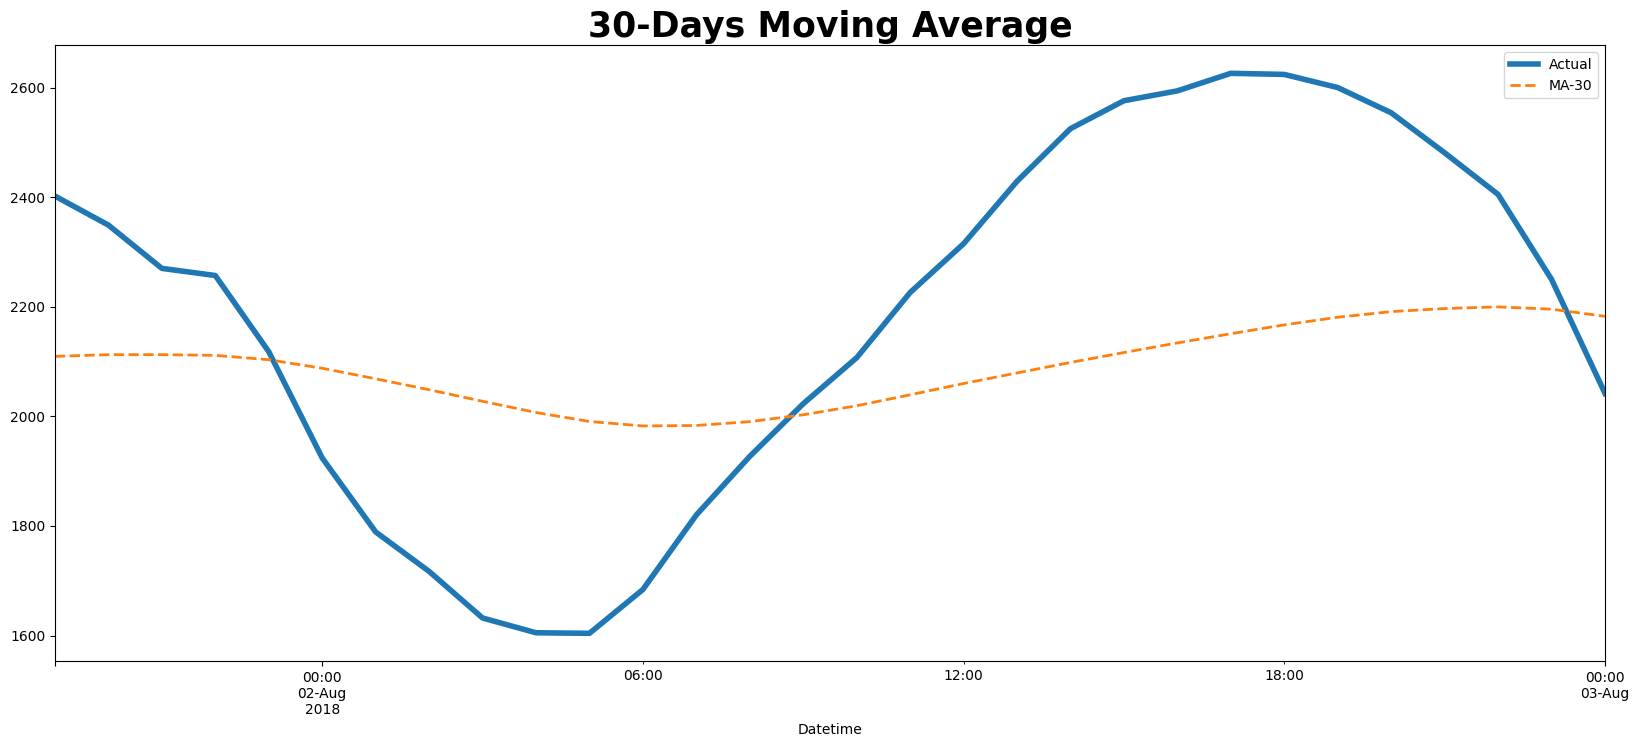

In [142]:
moving_average(df,30)

# Calculate exponential moving average

In [143]:
def ema(data, alpha):
    data['Exponential Moving Average'] = data['DAYTON_MW'].ewm(com=alpha).mean()
    # Limit the data to the last 100 observations
    actual = data['DAYTON_MW'][-100:]
    ema = data['Exponential Moving Average'][-100:]
    
    plt.figure(figsize=(20,8))
    actual.plot(label='Actual', lw=4)
    ema.plot(label='EMA with alpha -{}'.format(str(alpha)), ls='--', lw=2)
    plt.title('Alpha {}-EMA'.format(str(alpha)), weight='bold', fontsize=25)
    plt.legend()

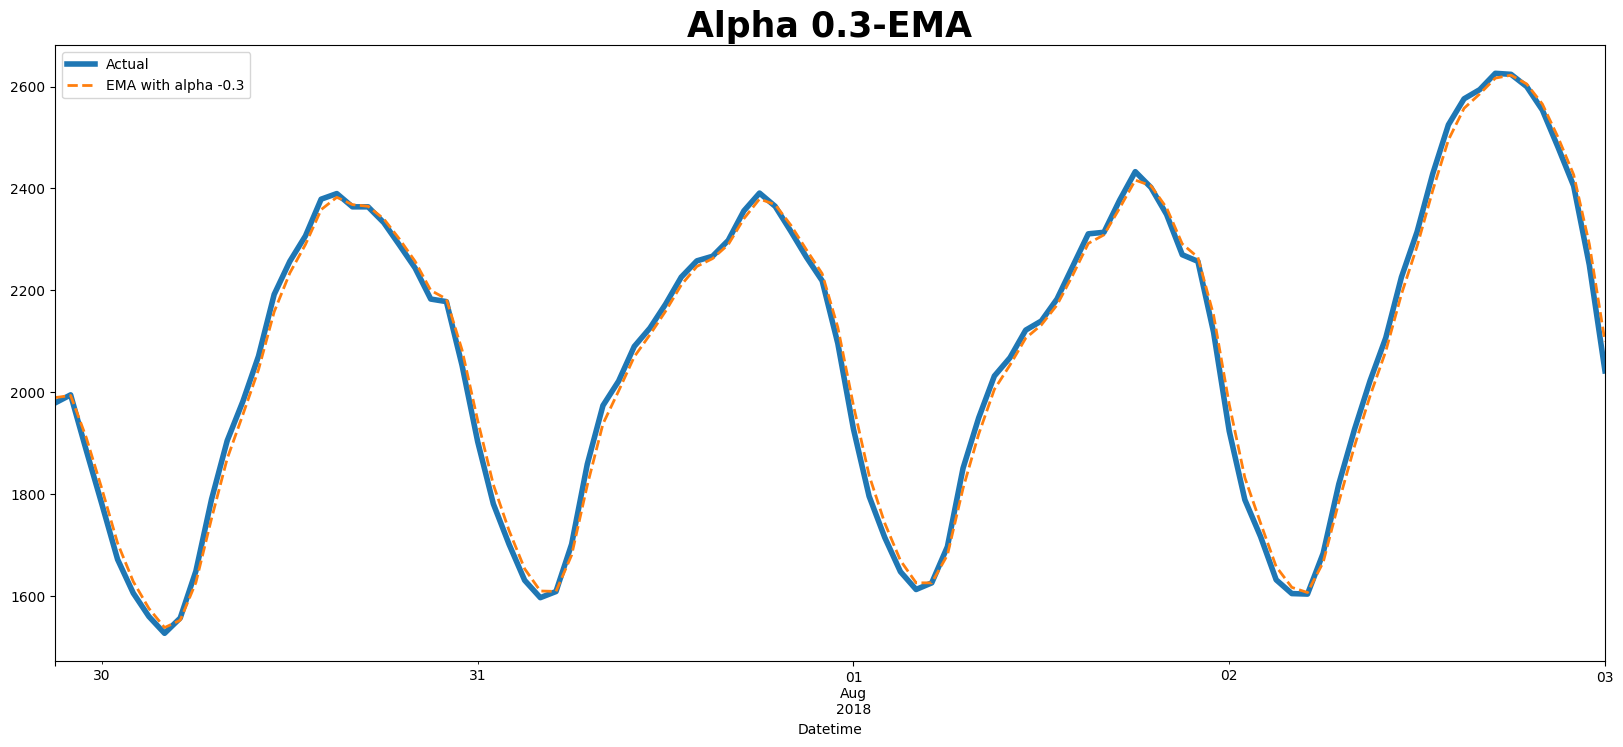

In [144]:
ema(df,0.3)

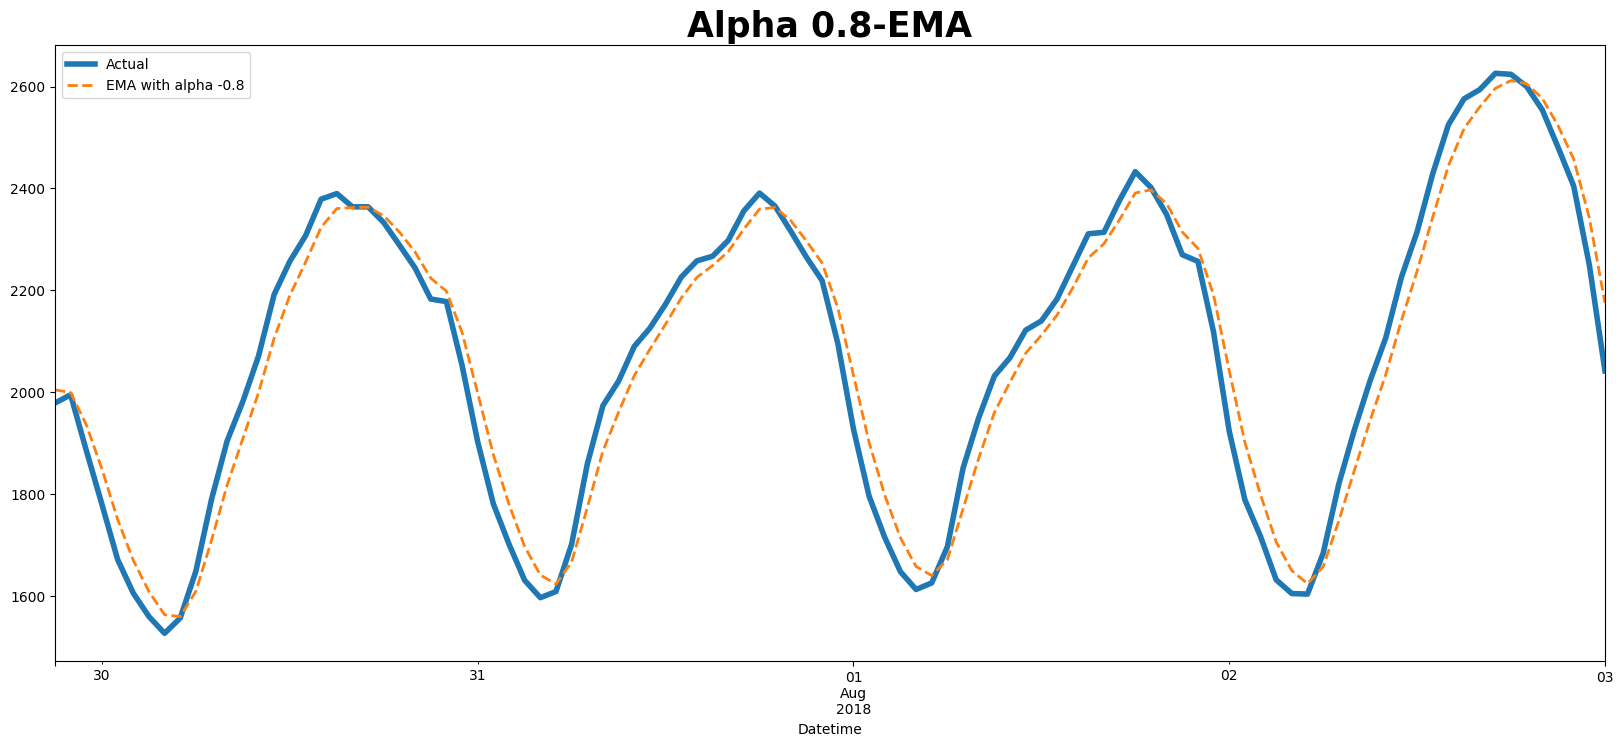

In [145]:
ema(df,0.8)

Split the data into train and test.

In [168]:
# Before building and training our model, let's split the data into training and testing
df_train, df_test = df['DAYTON_MW'][df['DAYTON_MW'].index < '2016-01-01'], df['DAYTON_MW'][df['DAYTON_MW'].index >= '2016-01-01']
print(f'The length of df train is :{len(df_train)}','\n',f'The length of df test is :{len(df_test)}')


The length of df train is :98595 
 The length of df test is :22680


In [169]:
df_train.head()

Datetime
2004-10-01 01:00:00    1621.0
2004-10-01 02:00:00    1536.0
2004-10-01 03:00:00    1500.0
2004-10-01 04:00:00    1434.0
2004-10-01 05:00:00    1489.0
Name: DAYTON_MW, dtype: float64

In [172]:
df_train= df_train.reset_index()
df_train.head()
df_train = df_train.rename(columns = {'Datetime':'ds','DAYTON_MW':'y'})

In [178]:
df_test= df_test.reset_index()
df_test.head()
df_test = df_test.rename(columns = {'Datetime':'ds','DAYTON_MW':'y'})

# Make predictions using Prophet

In [173]:
from prophet import Prophet
from prophet.plot import plot_plotly
# import plotly.offline as py

# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = Prophet(interval_width=0.95)

my_model.fit(df_train)

14:09:06 - cmdstanpy - INFO - Chain [1] start processing
14:10:40 - cmdstanpy - INFO - Chain [1] done processing


In [186]:
prophet_pred = my_model.predict(df_test[['ds']])

In [196]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error
mae = round(mean_absolute_error(df_test['y'], prophet_pred['yhat']), 3)
rmse = round(root_mean_squared_error(df_test['y'], prophet_pred['yhat']), 3)
mse = round(mean_squared_error(df_test['y'], prophet_pred['yhat']), 3)
print(f"The Mean absolute error is: {mae}")
print(f"The Mean squared error is: {mse}")
print(f"The Root Mean absolute error is: {rmse}")

The Mean absolute error is: 207.865
The Mean squared error is: 75741.269
The Root Mean absolute error is: 275.211


In [193]:
print(prophet_pred[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

                   ds         yhat   yhat_lower   yhat_upper
0 2016-01-01 00:00:00  1918.141256  1482.256853  2358.861773
1 2016-01-01 01:00:00  1798.611462  1383.537046  2249.300819
2 2016-01-01 02:00:00  1702.558070  1236.310922  2164.657172
3 2016-01-01 03:00:00  1641.070278  1220.663512  2096.682758
4 2016-01-01 04:00:00  1625.852792  1177.663568  2066.804403


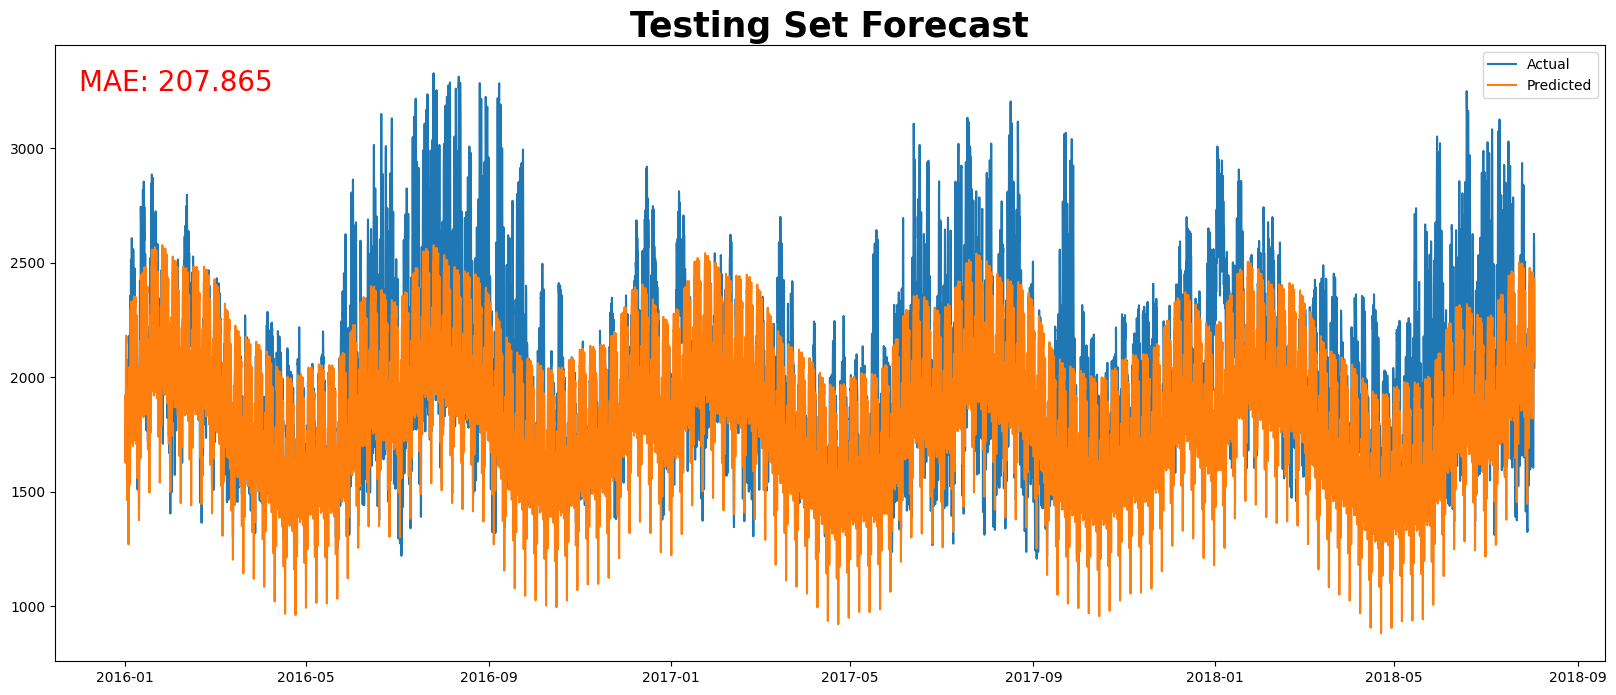

In [ ]:
# Visualize the prediction for the test data.
plt.figure(figsize=(20,8))
plt.plot(df_test['ds'], df_test['y'], label='Actual')
plt.plot(prophet_pred['ds'], prophet_pred['yhat'], label='Predicted')
plt.title('Test Forecasting', weight='bold', fontsize=40)
plt.text(16770, 3250, 'MAE: {}'.format(mae), fontsize=20, color='red')
plt.title('Testing Set Forecast', weight='bold', fontsize=25)
plt.legend()

Predict future values. Specifically for the next 7 days. (7 days are 168 hours)

In [229]:
# This time, we will use all data (train and test) to train our model
df= df3.copy()
df = df.reset_index()
new_df = df.rename(columns = {'Datetime':'ds','DAYTON_MW':'y'})
prophet_model2 = Prophet(
    interval_width=0.95,
    uncertainty_samples=0
)
prophet_model2.fit(new_df)
future_dates = prophet_model2.make_future_dataframe(periods=168, freq='h') 
my_model2 = prophet_model2.predict(future_dates)

08:19:58 - cmdstanpy - INFO - Chain [1] start processing
08:21:17 - cmdstanpy - INFO - Chain [1] done processing


In [230]:
new_df.tail()

,ds,y
121270,2018-01-01 20:00:00,2732.0
121271,2018-01-01 21:00:00,2724.0
121272,2018-01-01 22:00:00,2664.0
121273,2018-01-01 23:00:00,2614.0
121274,2018-01-02 00:00:00,2552.0


In [226]:
my_model2.tail()

,ds,trend,additive_terms,daily,weekly,yearly,multiplicative_terms,yhat
121434,2018-08-09 20:00:00,2039.768247,565.826077,223.999301,94.968273,246.858502,0.0,2605.594324
121435,2018-08-09 21:00:00,2039.771257,532.741043,192.562323,93.477696,246.701024,0.0,2572.512299
121436,2018-08-09 22:00:00,2039.774266,452.733034,114.282984,91.905745,246.544306,0.0,2492.507300
121437,2018-08-09 23:00:00,2039.777276,338.120064,1.493878,90.237840,246.388346,0.0,2377.897340
121438,2018-08-10 00:00:00,2039.780285,211.762725,-122.927659,88.457240,246.233143,0.0,2251.543010


<Figure size 2000x800 with 0 Axes>

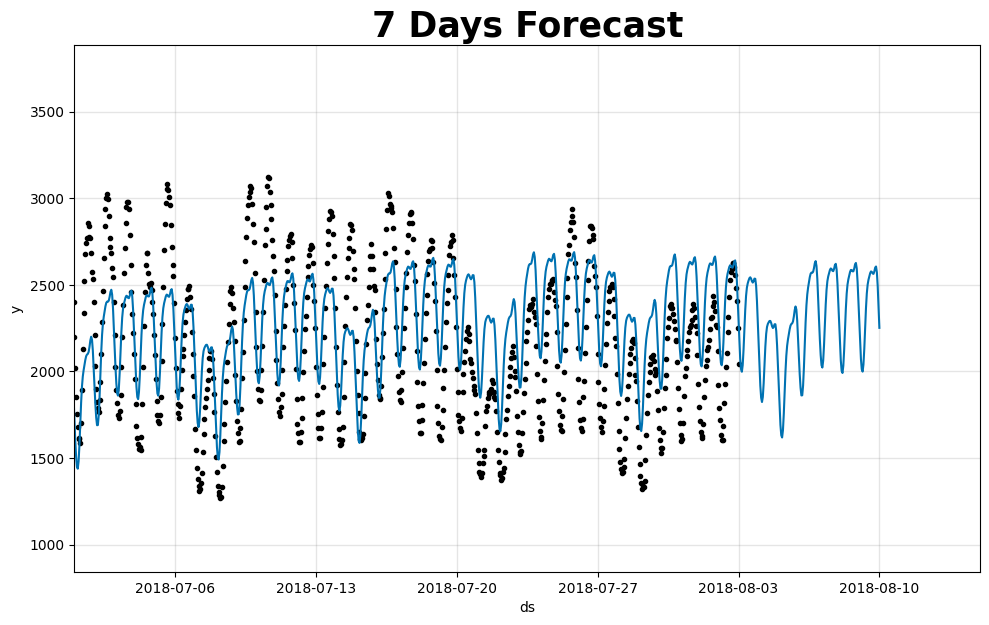

In [ ]:
# Visualize the prediction for the 7 predict dates.
plt.figure(figsize=(20,8))
fig = prophet_model2.plot(my_model2, uncertainty=True)
ax = fig.gca()
ax.set_xlim(pd.to_datetime(['2018-07-01', '2018-08-15']))
plt.title('7 Days Forecast', weight='bold', fontsize=25)
plt.show()

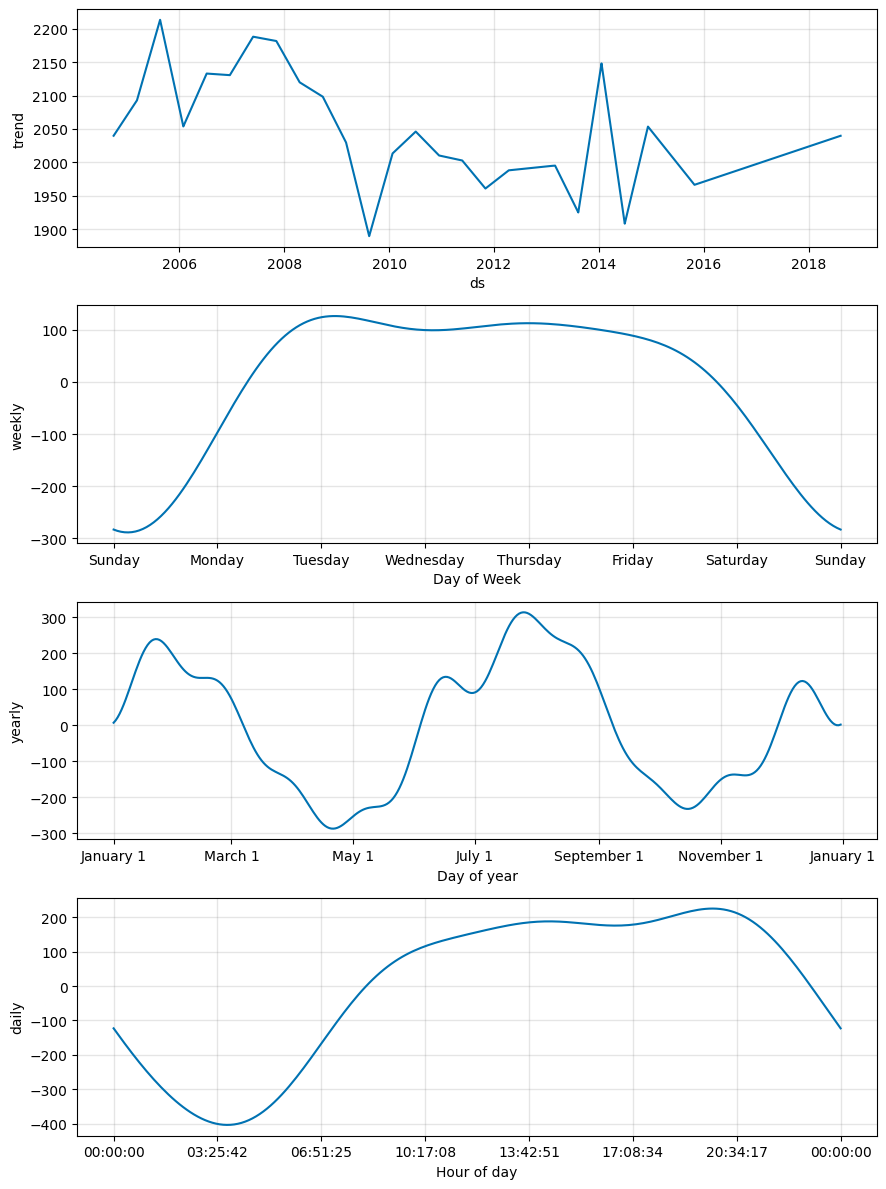

In [233]:
prophet_model2.plot_components(my_model2)
plt.show()

Predict values for the next 30 days using Prophet.

In [236]:
future_dates30 = prophet_model2.make_future_dataframe(periods=720, freq='h') # 720 hours are the the total hours of the month
my_model3 = prophet_model2.predict(future_dates30)

<Figure size 2000x800 with 0 Axes>

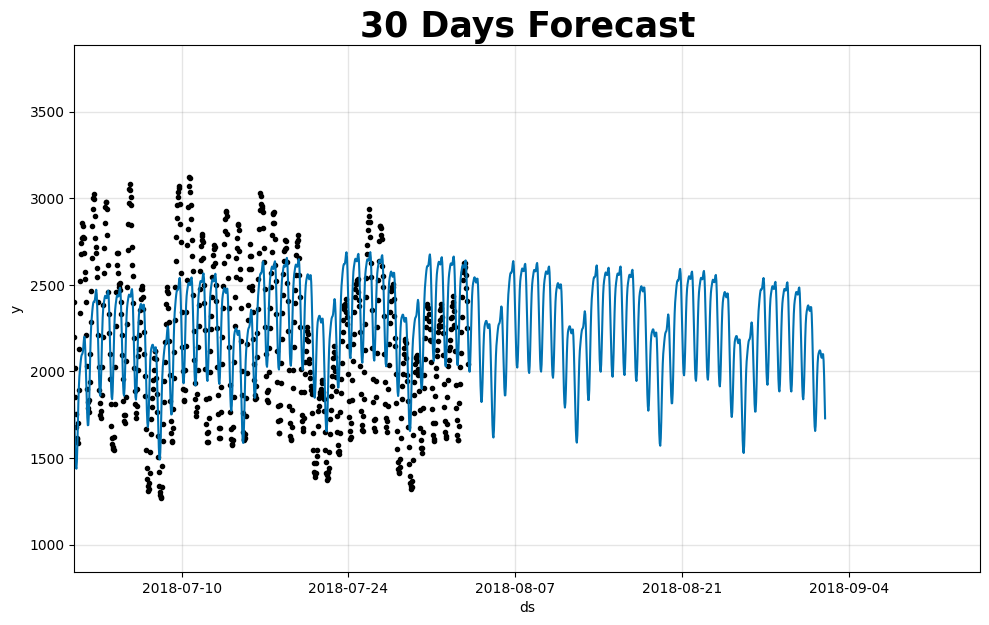

In [237]:
# Visualize the prediction for the test data.
plt.figure(figsize=(20,8))
fig = prophet_model2.plot(my_model3, uncertainty=True)
ax = fig.gca()
ax.set_xlim(pd.to_datetime(['2018-07-01',  '2018-09-15']))
plt.title('30 Days Forecast', weight='bold', fontsize=25)
plt.show()

# Implement ARMA Model

In [240]:
# Check for stationarity
from statsmodels.tsa.stattools import adfuller
df = df3.copy()
result = adfuller(df['DAYTON_MW'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])


MemoryError: Unable to allocate 65.7 MiB for an array with shape (71, 121203) and data type float64